In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split
from model import  Skeleton2Mesh
from tqdm import tqdm
import torch
import pandas as pd
from scipy.spatial.transform import Rotation as R

# Common configuration
# -------------------------
model_cfg = dict(
    num_joints=20,
    num_bones=19,
    gsd_dim=100,
    mlp_hidden=[256, 256],
    pe_freqs_bone=5,
    pe_freqs_order=2,
)

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device='cpu'

# -------------------------
# Model factory
# -------------------------
def build_model(*, use_euler=False, use_quat=False,use_6d=False):
    return Skeleton2Mesh(
        **model_cfg,
        use_euler=use_euler,
        use_quat=use_quat,
        use_6d=use_6d
    ).to(device)

# -------------------------
# Model instances
# -------------------------
quat_model     = build_model(use_quat=True)
euler_model    = build_model(use_euler=True)
rot6d_model    = build_model(use_6d=True)
no_euler_model = build_model()


euler_checkpoint_path = "new_data/checkpoint_best_val_loss_euler.pth"  
quat_checkpoint_path = "new_data/checkpoint_best_val_loss_quat.pth"    
rot6d_checkpoint_path = "new_data/checkpoint_best_val_loss_rot6d.pth"    
no_euler_checkpoint_path = "new_data/checkpoint_best_val_loss_no_euler.pth"  

# Load checkpoint
def load_model(model, checkpoint_path, device):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"],strict=False)
    model.to(device)
    model.eval()
    return model

euler_model = load_model(euler_model, euler_checkpoint_path, device)
quat_model  = load_model(quat_model,  quat_checkpoint_path,  device)
rot6d_model  = load_model(rot6d_model,  rot6d_checkpoint_path,  device)
no_euler_model = load_model(no_euler_model, no_euler_checkpoint_path, device)




C:\Users\dyros\AppData\Local\Temp\ipykernel_27232\377417790.py:52: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=device

In [2]:
def batch_quat_to_6d(quats_df):
    """
    Receives (N, 4) Quaternion DataFrame as input and 
    returns (N, 6) 6D Rotation Representation DataFrame.
    
    Features:
      - Preserves the Index of the input DataFrame (essential for concat).
      - Automatically assigns intuitive matrix component names (r11, r12, etc.) to column names.
      
    Args:
      quats_df: (N, 4) pandas DataFrame. Column order assumes [x, y, z, w].
      
    Returns:
      df_6d: (N, 6) pandas DataFrame.
    """
    # 1. Extract values and convert
    r = R.from_quat(quats_df.values)
    
    # 2. Rotation Matrix (N, 3, 3) -> slice only first 2 columns (N, 3, 2)
    rot_cols_only = r.as_matrix()[:, :, :2]
    
    # 3. Flatten (N, 6)
    rot_6d_flat = rot_cols_only.reshape(rot_cols_only.shape[0], -1)
    
    # 4. Generate column names (Row-major: row-first)
    # Column 1(x-axis): not r11, r21, r31 / Column 2(y-axis): r12, r22, r32 order
    # but reshape results in [r11, r12, r21, r22, r31, r32] order.
    col_names = ['r11', 'r12', 'r21', 'r22', 'r31', 'r32']
    
    # 5. Create DataFrame (preserving Index is important!)
    df_6d = pd.DataFrame(
        rot_6d_flat, 
        columns=col_names, 
        index=quats_df.index  # <--- Preserve original index
    )
    
    return df_6d


In [3]:
pose_list = ["BV_pose","FF_pose","L_pose","O8_pose","VV_pose","U_pose"]

for pose in pose_list:
    for num in range(1,5):
        hand_sync_data = pd.read_csv('C:/Users/dyros/Desktop/dummy_ws/exp/exp0106/' + pose + '/data/data_' + str(num) + '.csv') # fix path

        euler = hand_sync_data.iloc[:,-4:-1]
        quat = hand_sync_data.iloc[:,10:14]
        position = hand_sync_data.iloc[:,10:-12]
        rot_6d = batch_quat_to_6d(quat)

        # print(quat.shape,rot_6d.shape,position.shape)


        keywords = ['orientation', 'poses0', 'poses21', 'poses22', 'poses23', 'poses24', 'poses25']
        pattern = '|'.join(keywords)

        # 1) Find columns containing any of the keywords
        # mask_any_keyword = df_merged.columns.str.contains(pattern)
        mask_any_keyword = position.columns.str.contains(pattern)
        final_mask = ~mask_any_keyword 

        # 4) Apply mask to DataFrame
        # df_merged = df_merged.loc[:, final_mask]
        position_df = position.loc[:, final_mask]

        def data_gen(df,angle=None):
            if angle is not None:
                concat_df = pd.concat([df,angle],axis=1)
            else:
                concat_df = df
            dataset = torch.from_numpy(concat_df.to_numpy()).float()

            return dataset

        euler_input = data_gen(position_df,euler)
        quat_input = data_gen(position_df,quat)
        rot6d_input = data_gen(position_df, rot_6d)
        no_euler_input = data_gen(position_df,euler) 
        # print(quat_input.shape,rot6d_input.shape)

        with torch.no_grad():
            pred_euler = euler_model(euler_input)
            pred_quat  = quat_model(quat_input)
            pred_rot6d  = rot6d_model(rot6d_input)
            pred_no_e  = no_euler_model(no_euler_input)

        pred_euler = pred_euler.cpu().numpy()
        pred_quat  = pred_quat.cpu().numpy()
        pred_rot6d  = pred_rot6d.cpu().numpy()
        pred_no_e  = pred_no_e.cpu().numpy()

        df_euler = pd.DataFrame(
            pred_euler,
            columns=["angle1", "angle2", "angle3"]
        )
        df_quat = pd.DataFrame(
            pred_quat,
            columns=["angle1", "angle2", "angle3"]
        )
        df_rot6d = pd.DataFrame(
            pred_rot6d,
            columns=["angle1", "angle2", "angle3"]
        )
        df_no_e = pd.DataFrame(
            pred_no_e,
            columns=["angle1", "angle2", "angle3"]
        )

        df_euler = df_euler.ewm(alpha=0.1, adjust=False).mean()
        df_quat  = df_quat.ewm(alpha=0.1, adjust=False).mean()
        df_rot6d  = df_rot6d.ewm(alpha=0.1, adjust=False).mean()
        df_no_e  = df_no_e.ewm(alpha=0.1, adjust=False).mean()
        
        # if pose == "VV_pose" and num ==2:
        #     print(pred_rot6d)

        df_euler.to_csv('C:/Users/dyros/Desktop/dummy_ws/exp/exp0106/' + pose + '/result/euler_' + str(num) + '.csv', index=False)
        df_quat.to_csv('C:/Users/dyros/Desktop/dummy_ws/exp/exp0106/' + pose + '/result/quat_' + str(num) + '.csv', index=False)
        df_rot6d.to_csv('C:/Users/dyros/Desktop/dummy_ws/exp/exp0106/' + pose + '/result/rot6d_' + str(num) + '.csv', index=False)
        df_no_e.to_csv('C:/Users/dyros/Desktop/dummy_ws/exp/exp0106/' + pose + '/result/no_euler_' + str(num) + '.csv', index=False)


In [4]:
from scipy.interpolate import make_interp_spline
import numpy as np

radTodeg = 180 / 3.14159265358979323846
# radTodeg = 1
degTorad = 1 / radTodeg

pose_list = ['L','U','VV','BV','FF','O8']
num_list = ['1','2','3','4']


def teachnet_cal_var(teachnet=None,spline=False,ema=False,spline_num=400):
    idx = [4,13,17]
    x = teachnet.iloc[:,0] - teachnet.iloc[0,0]
    x = x * 1e-9

    var_teachnet_list = []

    for i ,y_idx in enumerate(idx):
        y = teachnet.iloc[:,y_idx]

        if spline:
            x_new = np.linspace(x.min(), x.max(),spline_num)
            spline = make_interp_spline(x,y,k=3)
            y_smooth = spline(x_new)

            if ema:
                alpha = 0.1
                y_ema = np.zeros_like(y_smooth)
                y_ema[0] = y_smooth[0]
    
                for j in range(1,len(y_smooth)):
                    y_ema[j] = alpha * y_smooth[j] + (1 - alpha) * y_ema[j-1]
    
                y_final = y_ema
    
            else:
                y_final = y_smooth

        else:
            y_final = y
        y_final = y_final 
        var_y = np.var(y_final)
        var_teachnet_list.append(var_y)
    
    return var_teachnet_list
         

data_list=[]
for pose in pose_list:
    euler_list=[]
    quat_list = []
    no_euler_list=[]
    rot6d_list=[]
    teachnet_list=[]
    GT_list=[]
    for num in num_list:
        euler = pd.read_csv('C:/Users/dyros/Desktop/dummy_ws/exp/exp0106/' + pose + '_pose/result/euler_' + num + '.csv')
        quat = pd.read_csv('C:/Users/dyros/Desktop/dummy_ws/exp/exp0106/' + pose + '_pose/result/quat_' + num + '.csv')
        no_e = pd.read_csv('C:/Users/dyros/Desktop/dummy_ws/exp/exp0106/' + pose + '_pose/result/no_euler_' + num + '.csv')
        rot = pd.read_csv('C:/Users/dyros/Desktop/dummy_ws/exp/exp0106/' + pose + '_pose/result/rot6d_' + num + '.csv')
        data_ori = pd.read_csv('C:/Users/dyros/Desktop/dummy_ws/exp/exp0106/' + pose + '_pose/data/data_' + num + '.csv')
        GT = data_ori.iloc[:,-11:-8].to_numpy() * degTorad

        if num=="1":num=""
        if pose=="U":
            teach_pose="V"
        elif pose=="O8":
            pose="o8"     
        else:
            teach_pose = pose
        teachnet = pd.read_csv('C:/Users/dyros/Desktop/dummy_ws/exp/exp1110/exp1103_teachnet/'+ teach_pose+ '_pose' + num + '.csv')



        # euler = euler * degTorad
        # quat = quat * degTorad
        # no_e = no_e * degTorad

        var_euler = np.var(euler, axis=0)   # (3,)
        var_quat  = np.var(quat,  axis=0)
        var_no_e  = np.var(no_e,  axis=0)
        var_rot  = np.var(rot,  axis=0)
        var_base = np.var(GT,axis=0)
        var_teachnet_list = teachnet_cal_var(teachnet=teachnet,spline=True,ema=False,spline_num=euler.shape[0])


        
        euler_list.append(var_euler)
        quat_list.append(var_quat)
        no_euler_list.append(var_no_e)
        rot6d_list.append(var_rot)
        teachnet_list.append(var_teachnet_list)
        GT_list.append(var_base)
    
    data_list.append([euler_list,quat_list,no_euler_list,rot6d_list,teachnet_list,GT_list])
    # print(rot6d_list,"\n")


data_array = np.array(data_list)









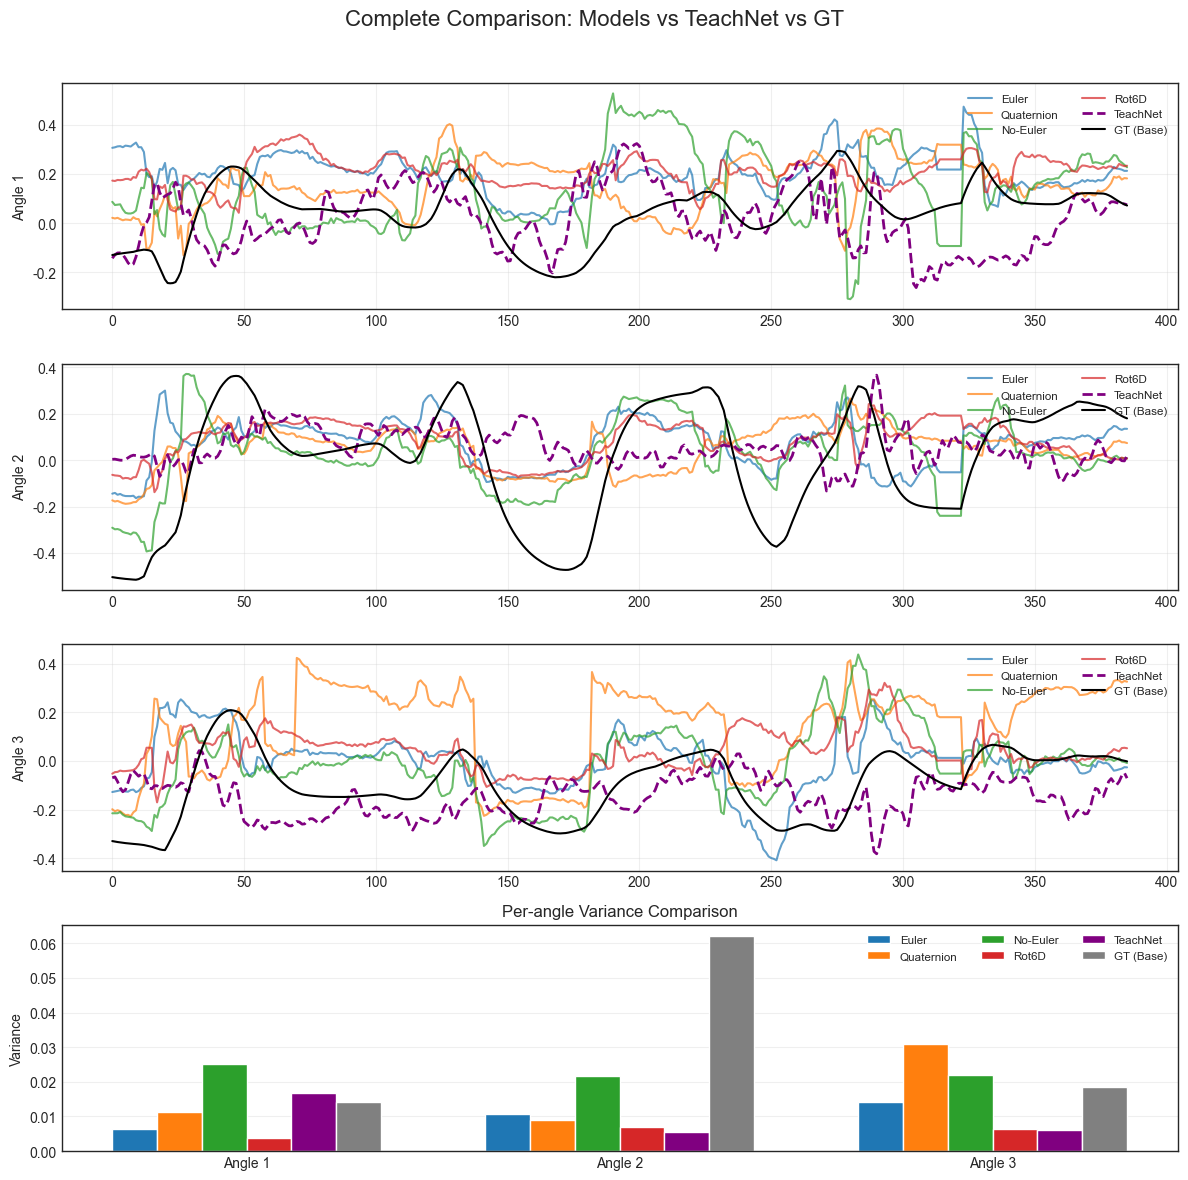

In [58]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

# --- 1. 환경 설정 및 상수 ---
radTodeg = 180 / 3.14159265358979323846
degTorad = 1 / radTodeg

# --- 2. 데이터 처리 함수 정의 ---

def teachnet_process(teachnet_df, spline=True, ema=False,spline_num=400):
    """
    TeachNet 데이터에서 지정된 인덱스의 값을 추출하고 보간(Spline) 및 평활화(EMA)를 수행합니다.
    분산(Variance)과 시계열 데이터(Values)를 모두 반환합니다.
    """
    idx = [4, 13, 17] # 각도 데이터 위치
    # 시간축 설정 (나노초 -> 초)
    x = (teachnet_df.iloc[:, 0] - teachnet_df.iloc[0, 0]).values * 1e-9
    
    processed_values = []
    variances = []

    for i, y_idx in enumerate(idx):
        y = teachnet_df.iloc[:, y_idx].values

        if spline:
            # 보간법 적용 (500개 샘플로 균일화)
            x_new = np.linspace(x.min(), x.max(), spline_num)
            spline_func = make_interp_spline(x, y, k=3)
            y_final = spline_func(x_new)
            
            if ema:
                alpha = 0.1
                y_ema = np.zeros_like(y_final)
                y_ema[0] = y_final[0]
                for j in range(1, len(y_final)):
                    y_ema[j] = alpha * y_final[j] + (1 - alpha) * y_ema[j-1]
                y_final = y_ema
        else:
            y_final = y

        processed_values.append(y_final)
        variances.append(np.var(y_final))
    
    # 리스트를 numpy array로 변환 (Time, 3)
    return np.array(processed_values).T, np.array(variances)

def data_gen(df, angle=None):
    if angle is not None:
        concat_df = pd.concat([df, angle], axis=1)
    else:
        concat_df = df
    return torch.from_numpy(concat_df.to_numpy()).float()

# --- 3. 데이터 로드 및 전처리 ---

# 파일 경로 설정 (사용자 경로에 맞춰 수정 필요)
base_path = 'C:/Users/dyros/Desktop/dummy_ws/exp/'
hand_sync_path = base_path + 'exp0106/O8_pose/data/data_3.csv'
teachnet_path = base_path + 'exp1110/exp1103_teachnet/v_pose.csv'

hand_sync_data = pd.read_csv(hand_sync_path)
teachnet_df = pd.read_csv(teachnet_path)

# 입력 데이터 추출
euler = hand_sync_data.iloc[:, -4:-1]
quat = hand_sync_data.iloc[:, 10:14]
position = hand_sync_data.iloc[:, 10:-12]

# 6D Rotation 변환 (batch_quat_to_6d 함수는 이미 정의되어 있다고 가정)
# 만약 없으면 quat 데이터를 그대로 사용하거나 별도 정의가 필요합니다.
rot_6d = batch_quat_to_6d(quat) 
GT = hand_sync_data.iloc[:, -11:-8].to_numpy() * degTorad

# Position 데이터 필터링 (불필요한 키워드 제거)
keywords = ['orientation', 'poses0', 'poses21', 'poses22', 'poses23', 'poses24', 'poses25']
pattern = '|'.join(keywords)
mask_any_keyword = position.columns.str.contains(pattern)
position_df = position.loc[:, ~mask_any_keyword]

# --- 4. 모델 추론 (Inference) ---

euler_input = data_gen(position_df, euler)
quat_input = data_gen(position_df, quat)
no_euler_input = data_gen(position_df, euler) 
rot6d_input = data_gen(position_df, rot_6d)

# 모델이 메모리에 로드되어 있어야 합니다.
with torch.no_grad():
    pred_euler = euler_model(euler_input).cpu().numpy()
    pred_quat  = quat_model(quat_input).cpu().numpy()
    pred_rot6d = rot6d_model(rot6d_input).cpu().numpy()
    pred_no_e  = no_euler_model(no_euler_input).cpu().numpy()

# TeachNet 데이터 처리
pred_teachnet, var_teachnet = teachnet_process(teachnet_df, spline=True, ema=False,spline_num=euler.shape[0])

# --- 5. 통계 계산 ---

var_euler = np.var(pred_euler, axis=0)
var_quat  = np.var(pred_quat, axis=0)
var_no_e  = np.var(pred_no_e, axis=0)
var_rot6d = np.var(pred_rot6d, axis=0)
var_base  = np.var(GT, axis=0)

# --- 6. 시각화 (Plotting) ---

angles_label = ["Angle 1", "Angle 2", "Angle 3"]
x_bar = np.arange(len(angles_label))
width = 0.12 # 막대 너비 조절

plt.figure(figsize=(12, 12))

# 1~3번 서브플롯: 각도별 시계열 데이터 비교
for i in range(3):
    plt.subplot(4, 1, i + 1)
    plt.plot(pred_euler[:, i], label="Euler", alpha=0.7)
    plt.plot(pred_quat[:, i], label="Quaternion", alpha=0.7)
    plt.plot(pred_no_e[:, i], label="No-Euler", alpha=0.7)
    plt.plot(pred_rot6d[:, i], label="Rot6D", alpha=0.7)
    # TeachNet은 점선으로 표시하여 구분
    plt.plot(pred_teachnet[:, i], label="TeachNet", linestyle='--', color='purple', linewidth=2)
    plt.plot(GT[:, i], label="GT (Base)", color='black', linewidth=1.5)
    
    plt.ylabel(angles_label[i])
    plt.legend(loc='upper right', ncol=2, fontsize='small')
    plt.grid(True, alpha=0.3)

# 4번 서브플롯: 분산(Variance) 비교 막대 그래프
plt.subplot(4, 1, 4)
plt.bar(x_bar - 2.5 * width, var_euler, width, label="Euler")
plt.bar(x_bar - 1.5 * width, var_quat,  width, label="Quaternion")
plt.bar(x_bar - 0.5 * width, var_no_e,  width, label="No-Euler")
plt.bar(x_bar + 0.5 * width, var_rot6d, width, label="Rot6D")
plt.bar(x_bar + 1.5 * width, var_teachnet, width, label="TeachNet", color='purple')
plt.bar(x_bar + 2.5 * width, var_base,  width, label="GT (Base)", color='gray')

plt.xticks(x_bar, angles_label)
plt.ylabel("Variance")
plt.title("Per-angle Variance Comparison")
plt.legend(loc='upper right', ncol=3, fontsize='small')
plt.grid(axis="y", alpha=0.3)

plt.suptitle("Complete Comparison: Models vs TeachNet vs GT", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [6]:
# import pandas as pd
# import numpy as np
# import torch
# import matplotlib.pyplot as plt
# from scipy.interpolate import make_interp_spline

# # 1~3번 서브플롯: 각도별 시계열 데이터 비교
# for i in range(3):
#     plt.subplot(4, 1, i + 1)
#     plt.plot(pred_euler[:, i], label="Euler", alpha=0.7)
#     plt.plot(pred_quat[:, i], label="Quaternion", alpha=0.7)
    
    
#     plt.ylabel(angles_label[i])
#     plt.legend(loc='upper right', ncol=2, fontsize='small')
#     plt.grid(True, alpha=0.3)

# # 4번 서브플롯: 분산(Variance) 비교 막대 그래프
# plt.subplot(4, 1, 4)
# plt.plot(euler)

# # plt.xticks(x_bar, angles_label)
# # plt.ylabel("Variance")
# plt.title("Per-angle Variance Comparison")
# plt.legend(loc='upper right', ncol=3, fontsize='small')
# plt.grid(axis="y", alpha=0.3)

# plt.suptitle("Complete Comparison: Models vs TeachNet vs GT", fontsize=16)
# # plt.tight_layout(rect=[0, 0, 1, 0.96])
# plt.show()

In [7]:
# import matplotlib.pyplot as plt
# import matplotlib.ticker as ticker
# import numpy as np

# # 1. 데이터 계산 (기존 로직 유지 + Max Abs Error 추가)
# # -------------------------------------------------------
# names = ['Euler', 'Quaternion', 'No-Euler', 'rot6d', 'base']
# colors = ['lightblue', 'lightgreen', 'lightcoral', 'wheat', 'mediumaquamarine']

# # A. Variance 데이터 (일관성)
# var_plot_data = [
#     np.var(pred_euler, axis=0),
#     np.var(pred_quat,  axis=0),
#     np.var(pred_no_e,  axis=0),
#     np.var(pred_rot6d, axis=0),
#     np.var(GT,         axis=0)
# ]

# # B. MSE 데이터 (평균 정확도)
# mse_plot_data = [
#     np.mean((pred_euler )**2, axis=0),
#     np.mean((pred_quat )**2, axis=0),
#     np.mean((pred_no_e )**2, axis=0),
#     np.mean((pred_rot6d )**2, axis=0),
#     np.mean((GT )**2, axis=0)
# ]

# # C. Max Absolute Error 데이터 (최대 오차 - Worst Case)
# # np.abs(pred - GT)의 axis=0(배치 방향)에서의 최댓값을 구합니다.
# max_abs_plot_data = [
#     np.max(np.abs(pred_euler ), axis=0),
#     np.max(np.abs(pred_quat ),  axis=0),
#     np.max(np.abs(pred_no_e ),  axis=0),
#     np.max(np.abs(pred_rot6d ), axis=0),
#     np.max(np.abs(GT ),         axis=0) # base는 0
# ]

# # 2. Plot 설정
# # -------------------------------------------------------
# angles = ["Angle 1", "Angle 2", "Angle 3"]
# x = np.arange(len(angles))
# width = 0.15 

# FS_SUPTITLE = 22
# FS_TITLE = 18
# FS_LABEL = 15
# FS_TICK = 13
# FS_LEGEND = 14

# # 3개의 서브플롯 생성 (figsize 높이를 20으로 조절)
# fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 20))
# fig.subplots_adjust(hspace=0.45)

# # -------------------------------------------------------
# # [A] Variance Plot (Output 일관성)
# # -------------------------------------------------------
# for j in range(5):
#     ax1.bar(x + (j - 2) * width, var_plot_data[j], width, 
#             color=colors[j], edgecolor='black', label=names[j])

# ax1.set_title("Per-angle Output Variation (Variance)", fontweight='bold', fontsize=FS_TITLE)
# ax1.set_ylabel("Variance", fontsize=FS_LABEL)

# # -------------------------------------------------------
# # [B] MSE Plot (평균 예측 정확도)
# # -------------------------------------------------------
# for j in range(5):
#     ax2.bar(x + (j - 2) * width, mse_plot_data[j], width, 
#             color=colors[j], edgecolor='black')

# ax2.set_title("Per-angle Prediction Error (MSE)", fontweight='bold', fontsize=FS_TITLE)
# ax2.set_ylabel("MSE", fontsize=FS_LABEL)

# # -------------------------------------------------------
# # [C] Max Absolute Error Plot (최대 예측 오차) [NEW]
# # -------------------------------------------------------
# for j in range(5):
#     ax3.bar(x + (j - 2) * width, max_abs_plot_data[j], width, 
#             color=colors[j], edgecolor='black')

# ax3.set_title("Per-angle Max Absolute Error (Max Abs Error)", fontweight='bold', fontsize=FS_TITLE)
# ax3.set_ylabel("Max Abs Error", fontsize=FS_LABEL)

# # -------------------------------------------------------
# # 공통 레이아웃 설정 루프
# # -------------------------------------------------------
# for ax in [ax1, ax2, ax3]:
#     ax.set_xticks(x)
#     ax.set_xticklabels(angles, fontsize=FS_LABEL)
#     ax.tick_params(axis='y', labelsize=FS_TICK)
#     ax.grid(axis='y', linestyle='--', alpha=0.6)

# # -------------------------------------------------------
# # 3. 마무리 (범례 및 타이틀)
# # -------------------------------------------------------
# # 범례를 가장 첫 번째 그래프 위에 가로로 길게 배치
# ax1.legend(loc='upper center', ncol=5, fontsize=FS_LEGEND, bbox_to_anchor=(0.5, 1.25))

# fig.suptitle("Inference Performance Analysis: Variance, MSE & Max Absolute Error", 
#              fontsize=FS_SUPTITLE, fontweight='bold', y=0.98)

# plt.tight_layout(rect=[0, 0.03, 1, 0.94])
# plt.show()

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import HTML
import re

def visualize_hand_sequence(df, bone_parents, bone_children, skip_frames=1):
    """
    df: 입력 데이터프레임
    bone_parents, bone_children: 뼈대 연결 정보
    skip_frames: 데이터가 너무 많을 경우 몇 프레임마다 그릴지 설정 (기본 1: 모든 프레임)
    """
    
    # ---------------------------------------------------------
    # 1. DataFrame에서 Landmark 좌표 추출 (Parsing)
    # ---------------------------------------------------------
    print("Extracting data from DataFrame...")
    
    # 컬럼명에서 숫자(인덱스)와 축(x,y,z) 추출을 위한 정규식
    # 예: field.pose_array.poses1.position.x -> index=1, axis='x'
    pattern = re.compile(r'field\.pose_array\.poses(\d+)\.position\.([xyz])')
    
    # 데이터프레임에 있는 모든 pose 인덱스 찾기
    indices = set()
    for col in df.columns:
        match = pattern.search(col)
        if match:
            indices.add(int(match.group(1)))
    
    sorted_indices = sorted(list(indices))
    num_joints = len(sorted_indices)
    
    if num_joints == 0:
        raise ValueError("DataFrame에서 'field.pose_array.poses...' 형태의 컬럼을 찾을 수 없습니다.")
    
    print(f"Detected {num_joints} joints. Indices: {sorted_indices[:5]} ... {sorted_indices[-5:]}")

    # (Time, Joints, 3) 형태로 데이터 변환
    num_frames = len(df)
    data_3d = np.zeros((num_frames, num_joints, 3)) # (T, J, 3)
    
    # DataFrame 컬럼 -> Numpy 배열 매핑
    # sorted_indices의 순서대로 0번 조인트, 1번 조인트... 로 매핑합니다.
    for i, original_idx in enumerate(sorted_indices):
        for j, axis in enumerate(['x', 'y', 'z']):
            col_name = f"field.pose_array.poses{original_idx}.position.{axis}"
            if col_name in df.columns:
                data_3d[:, i, j] = df[col_name].values
            else:
                print(f"Warning: Missing column {col_name}")

    # 데이터 다운샘플링 (애니메이션 속도 및 렌더링 시간 최적화)
    data_3d = data_3d[::skip_frames]
    
    # ---------------------------------------------------------
    # 2. 3D 애니메이션 설정
    # ---------------------------------------------------------
    print("Generating animation...")
    
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # 시각화 범위 고정 (데이터 전체의 min/max 기준)
    # 이렇게 해야 손이 움직일 때 카메라가 흔들리지 않습니다.
    all_x = data_3d[:, :, 0].flatten()
    all_y = data_3d[:, :, 1].flatten()
    all_z = data_3d[:, :, 2].flatten()
    
    margin = 0.05
    ax.set_xlim(all_x.min() - margin, all_x.max() + margin)
    ax.set_ylim(all_y.min() - margin, all_y.max() + margin)
    ax.set_zlim(all_z.min() - margin, all_z.max() + margin)
    
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title("Hand Landmark Sequence")

    # 초기화: 점(Scatter)과 선(Lines) 객체 생성
    # joints: 각 랜드마크 점
    scat = ax.scatter([], [], [], c='r', s=20, depthshade=True)
    
    # bones: 뼈대 선분들
    lines = []
    # bone_parents와 bone_children을 묶어서 연결 정보 생성
    connections = list(zip(bone_parents, bone_children))
    
    for _ in connections:
        line, = ax.plot([], [], [], 'b-', linewidth=1.5) # 파란색 실선
        lines.append(line)

    # ---------------------------------------------------------
    # 3. 프레임 업데이트 함수
    # ---------------------------------------------------------
    def update(frame):
        # 현재 프레임의 포즈 (Joints, 3)
        current_pose = data_3d[frame] 
        
        # 1. 점 업데이트
        # scatter는 set_data(2D)와 set_3d_properties(Z)를 따로 해줘야 함 (Matplotlib 버전에 따라 다름)
        # 가장 안전한 방법은 _offsets3d 프로퍼티를 직접 수정하는 것입니다.
        scat._offsets3d = (current_pose[:, 0], current_pose[:, 1], current_pose[:, 2])
        
        # 2. 선(Bone) 업데이트
        for line, (parent, child) in zip(lines, connections):
            # parent 인덱스와 child 인덱스가 데이터 범위 내에 있는지 확인
            if parent < num_joints and child < num_joints:
                x_pts = [current_pose[parent, 0], current_pose[child, 0]]
                y_pts = [current_pose[parent, 1], current_pose[child, 1]]
                z_pts = [current_pose[parent, 2], current_pose[child, 2]]
                
                line.set_data(x_pts, y_pts)
                line.set_3d_properties(z_pts)
            
        return [scat] + lines

    # ---------------------------------------------------------
    # 4. 애니메이션 생성 및 HTML 변환
    # ---------------------------------------------------------
    anim = animation.FuncAnimation(
        fig, update, frames=len(data_3d), interval=50, blit=True
    )
    
    # Jupyter Notebook에 표시하기 위해 HTML로 변환
    # to_jshtml()은 별도의 ffmpeg 설치 없이 브라우저 JS로 재생합니다.
    return HTML(anim.to_jshtml())

# =================================================================
# 사용 예시 (User's Context)
# =================================================================

# 1. 토폴로지 정의 (주신 데이터)
bone_parents = [0, 1, 2, 3,       # Thumb
                0, 5, 6, 7, 8,    # Index
                0, 10, 11, 12, 13, # Middle
                0, 15, 16, 17, 18  # Ring
               ]

bone_children = [1, 2, 3, 4,
                 5, 6, 7, 8, 9,
                 10,11,12,13,14,
                 15,16,17,18,19]

# 2. 실행 (df는 사용자의 DataFrame 변수라고 가정)
# 만약 df가 이미 메모리에 있다면 아래 주석을 풀고 실행하세요.
# 데이터가 너무 길면 skip_frames를 2, 5 등으로 늘리세요.

# visualize_hand_sequence(position_df, bone_parents, bone_children, skip_frames=3)

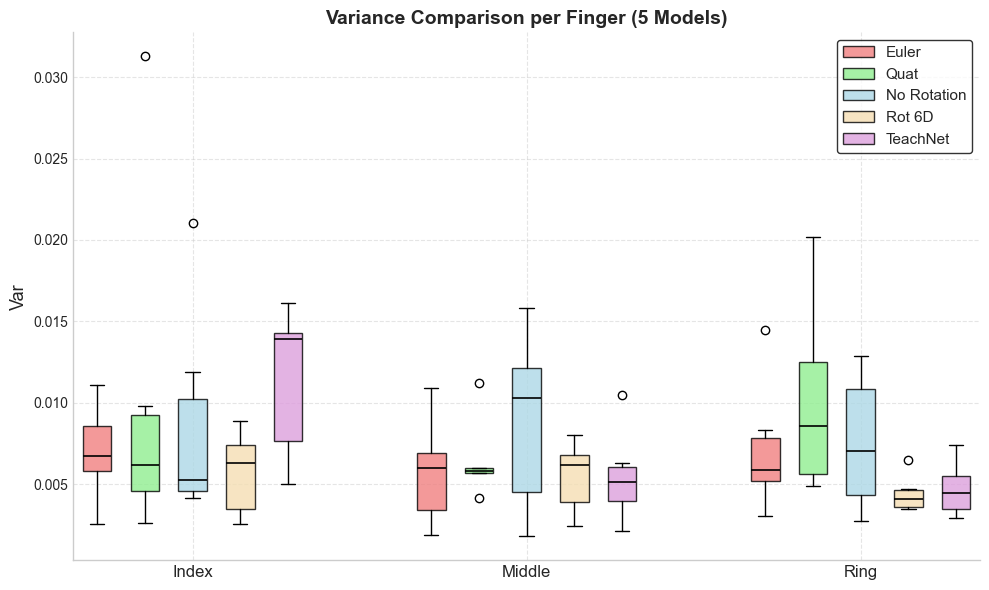

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# (가정) data_array가 이미 로드되어 있다고 가정합니다.
# data_array shape 예시: (Batch, Models, Ticks, Fingers) 등

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 6)) # 가로 길이를 조금 늘렸습니다 (데이터가 많아져서)

# 데이터 추출
mean_data = np.mean(data_array[:,:,:,:], axis=2)
euler_data = mean_data[:,0,:]
quat_data = mean_data[:,1,:]
no_euler_data = mean_data[:,2,:]
rot6d_data = mean_data[:,3,:]  # [NEW] 6D Rotation 데이터
teach_data = mean_data[:,4,:]

# 색상 5개 정의 (Rot6D용 색상 추가: wheat)
colors = ['lightcoral', 'lightgreen', 'lightblue', 'wheat', 'plum']

# Boxplot 위치 설정 로직
# 그룹 간 간격을 고려하여 배치:
# Group 1 (Index): 1, 2, 3, 4, 5
# Group 2 (Middle): 8, 9, 10, 11, 12
# Group 3 (Ring): 15, 16, 17, 18, 19

# 1. Euler
b1 = ax.boxplot(euler_data, positions=[1, 8, 15], widths=0.6,
                patch_artist=True,
                boxprops=dict(facecolor=colors[0], alpha=0.8, edgecolor='black'),
                medianprops=dict(color='black', linewidth=1.2))

# 2. Quat
b2 = ax.boxplot(quat_data, positions=[2, 9, 16], widths=0.6,
                patch_artist=True,
                boxprops=dict(facecolor=colors[1], alpha=0.8, edgecolor='black'),
                medianprops=dict(color='black', linewidth=1.2))

# 3. No Rotation
b3 = ax.boxplot(no_euler_data, positions=[3, 10, 17], widths=0.6,
                patch_artist=True,
                boxprops=dict(facecolor=colors[2], alpha=0.8, edgecolor='black'),
                medianprops=dict(color='black', linewidth=1.2))

# 4. Rot 6D [NEW]
b4 = ax.boxplot(rot6d_data, positions=[4, 11, 18], widths=0.6,
                patch_artist=True,
                boxprops=dict(facecolor=colors[3], alpha=0.8, edgecolor='black'),
                medianprops=dict(color='black', linewidth=1.2))

# 5. TeachNet
b5 = ax.boxplot(teach_data, positions=[5, 12, 19], widths=0.6,
                patch_artist=True,
                boxprops=dict(facecolor=colors[4], alpha=0.8, edgecolor='black'),
                medianprops=dict(color='black', linewidth=1.2))

# 축 설정 (각 그룹의 중앙인 3, 10, 17에 라벨 배치)
ax.set_xticks([3, 10, 17])
ax.set_xticklabels(['Index', 'Middle', 'Ring'], fontsize=12)
ax.set_ylabel('Var', fontsize=13)
ax.set_title('Variance Comparison per Finger (5 Models)', fontsize=14, fontweight='bold')

# 범례 업데이트 (5개 항목)
ax.legend([b1["boxes"][0], b2["boxes"][0], b3["boxes"][0], b4["boxes"][0], b5["boxes"][0]],
          ['Euler', 'Quat', 'No Rotation', 'Rot 6D', 'TeachNet'],
          loc='upper right', fontsize=11, frameon=True, edgecolor='black')

# 격자 및 외곽선 정리
ax.grid(True, linestyle='--', alpha=0.5)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

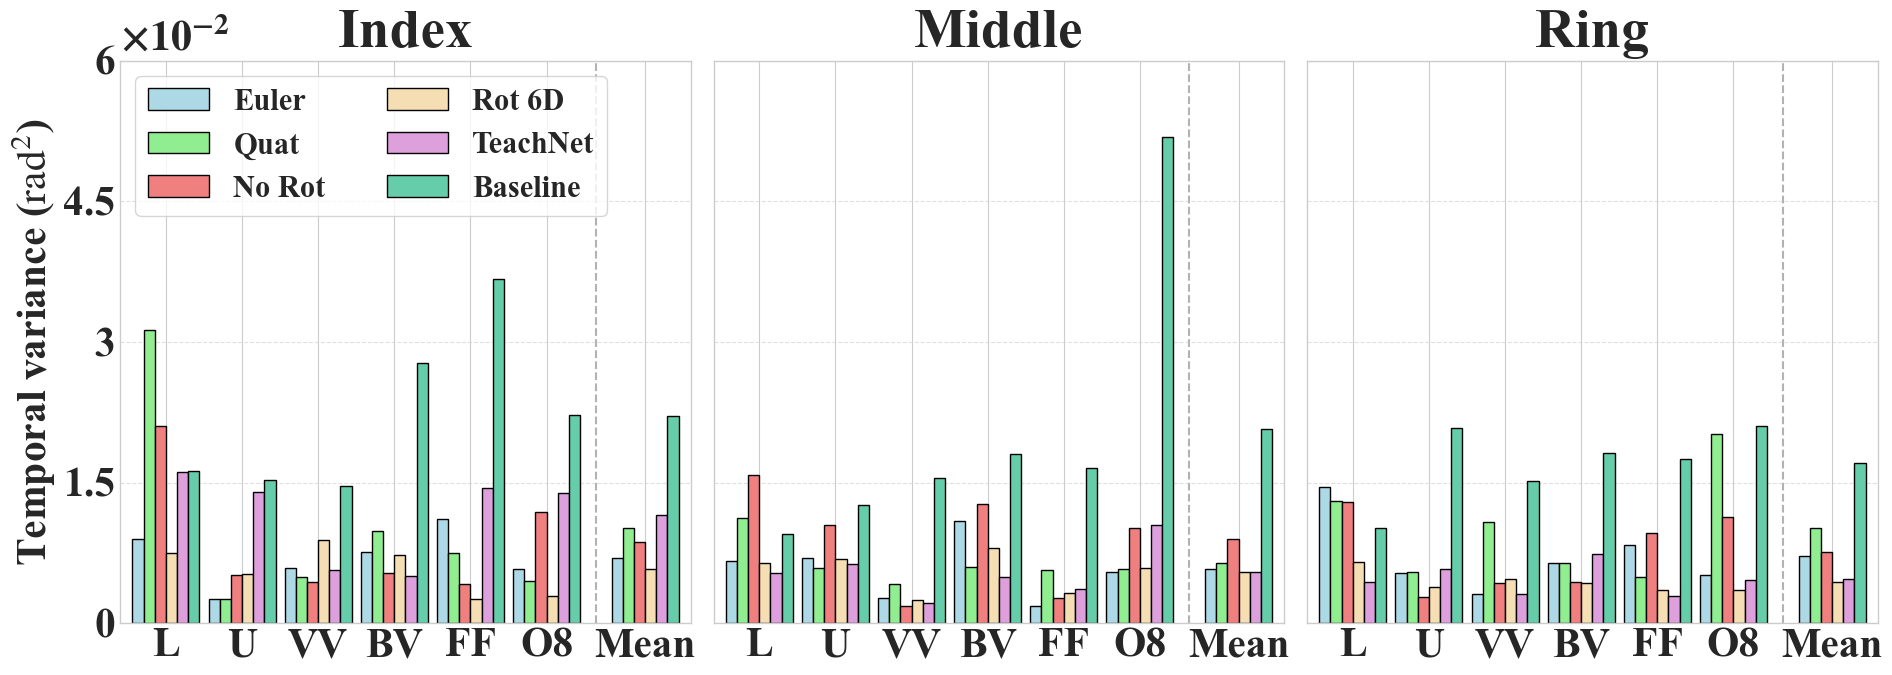

Final figure saved to: comparison_result.pdf

                             NUMERICAL RESULTS (Temporal Variance)                             

🔹 Finger: Index
-----------------------------------------------------------------------------------------------
Model        |          L |          U |         VV |         BV |         FF |         O8 |       Mean
-----------------------------------------------------------------------------------------------
Euler        |   0.008952 |   0.002560 |   0.005838 |   0.007585 |   0.011073 |   0.005799 |   0.006968
Quat         |   0.031276 |   0.002605 |   0.004916 |   0.009823 |   0.007509 |   0.004487 |   0.010103
No Rot       |   0.021012 |   0.005188 |   0.004421 |   0.005313 |   0.004165 |   0.011887 |   0.008664
Rot 6D       |   0.007476 |   0.005271 |   0.008908 |   0.007318 |   0.002590 |   0.002873 |   0.005739
TeachNet     |   0.016123 |   0.013955 |   0.005627 |   0.005025 |   0.014387 |   0.013875 |   0.011499
Baseline     |   0.016219

In [10]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# =====================================================
# Font: Times New Roman (global)
# =====================================================
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "stix"   # Times-like math glyphs without requiring LaTeX
plt.rcParams["axes.unicode_minus"] = False  # keep minus sign consistent

# =====================================================
# Data preparation
# =====================================================

# (Assume mean_data is already defined)
euler_data    = np.transpose(mean_data[:, 0, :])
quat_data     = np.transpose(mean_data[:, 1, :])
no_euler_data = np.transpose(mean_data[:, 2, :])
rot6d_data    = np.transpose(mean_data[:, 3, :])
teach_data    = np.transpose(mean_data[:, 4, :])
GT_data       = np.transpose(mean_data[:, 5, :])

euler_mean    = euler_data.mean(axis=1, keepdims=True)
quat_mean     = quat_data.mean(axis=1, keepdims=True)
no_euler_mean = no_euler_data.mean(axis=1, keepdims=True)
rot6d_mean    = rot6d_data.mean(axis=1, keepdims=True)
teach_mean    = teach_data.mean(axis=1, keepdims=True)
GT_mean       = GT_data.mean(axis=1, keepdims=True)

all_data = [
    np.hstack((euler_data, euler_mean)),
    np.hstack((quat_data, quat_mean)),
    np.hstack((no_euler_data, no_euler_mean)),
    np.hstack((rot6d_data, rot6d_mean)),
    np.hstack((teach_data, teach_mean)),
    np.hstack((GT_data, GT_mean)),
]

# =====================================================
# Plot configuration
# =====================================================

# --- MODIFIED: increase category spacing + keep L~O8 shift + keep Mean not too far right
CAT_SPACING = 1.25
x = np.arange(7, dtype=float) * CAT_SPACING

BASE_SHIFT = 0.18
MEAN_GAP   = 0.55

x[:-1] += BASE_SHIFT
x[-1]  += MEAN_GAP


# --- END MODIFIED

# placeholder (will be overwritten by group-width scheme below, kept for compatibility)
width = 0.15

labels = pose_list + [r"$\mathbf{Mean}$"]
if len(labels) > 1:
    labels[1] = "U"
labels[-1] = "Mean"

titles = ["Index", "Middle", "Ring"]

colors = [
    "lightblue",
    "lightgreen",
    "lightcoral",
    "wheat",
    "plum",
    "mediumaquamarine",
]

names = ["Euler", "Quat", "No Rot", "Rot 6D", "TeachNet", "Baseline"]

# Font sizes
FS_TITLE  = 40
FS_LABEL  = 30
FS_TICK   = 30
FS_LEGEND = 22

# =====================================================
# Figure & layout
# =====================================================

fig, axes = plt.subplots(1, 3, figsize=(19, 7.5))

fig.subplots_adjust(
    left=0.06,
    right=0.985,
    bottom=0.15,
    top=0.9,
    wspace=0.04,
)

# =====================================================
# Formatter
# =====================================================

def specific_formatter(x, pos):
    val = x * 100
    if abs(val - round(val)) < 1e-9:
        return f"{int(val)}"
    else:
        return f"{val:.1f}"

# =====================================================
# Plot per finger
# =====================================================

Y_LIMIT = 0.06

# --- MODIFIED: slightly reduce group width to increase category-level separation while keeping bars thick
n_models = len(all_data)
group_width = 1.1
width = group_width / n_models
offsets = (np.arange(n_models) - (n_models - 1) / 2.0) * width

RIGHT_PAD = 0.75
LEFT_PAD  = 0.75
# --- END MODIFIED

for i, ax in enumerate(axes):
    for j, data in enumerate(all_data):

        bar_x = x + offsets[j]

        ax.bar(
            bar_x,
            data[i],
            width,
            label=names[j],
            color=colors[j],
            edgecolor="black",
            linewidth=1.0,
        )

    # Mean separator (between O8 and Mean)
    ax.axvline(
        x=(x[-2] + x[-1]) / 2.0,
        linestyle="--",
        linewidth=1.5,
        color="gray",
        alpha=0.6,
        zorder=0,
    )

    # Title
    ax.set_title(titles[i], fontweight="bold", fontsize=FS_TITLE, pad=10)

    # X-axis
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=FS_LABEL, fontweight="bold")
    ax.set_xlim(x[0] - LEFT_PAD, x[-1] + RIGHT_PAD)

    # Y-axis
    if i == 0:
        ax.set_ylabel(
            r"Temporal variance ($\mathrm{rad}^2$)",
            fontsize=FS_LABEL,
            fontweight="bold",
        )
        ax.text(
            0.0,
            1.02,
            r"$\mathbf{\times 10^{-2}}$",
            transform=ax.transAxes,
            fontsize=FS_LABEL,
            fontweight="bold",
            ha="left",
        )
    else:
        ax.set_ylabel("")
        ax.tick_params(axis="y", labelleft=False)  # <<< MODIFIED >>> remove only the numbers (0, 1.5, 3, ...)

    ax.tick_params(axis="x", labelsize=FS_TICK)
    ax.tick_params(axis="y", labelsize=FS_TICK)

    for label in ax.get_yticklabels():
        label.set_fontweight("bold")

    ax.grid(axis="y", linestyle="--", alpha=0.6)

    ax.set_ylim(0, Y_LIMIT)
    ax.set_yticks([0, 0.015, 0.03, 0.045, 0.06])
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(specific_formatter))

# =====================================================
# Legend
# =====================================================

leg = axes[0].legend(  # <<< MODIFIED >>> keep a handle for bbox_extra_artists
    loc="upper left",
    ncol=2,
    prop={"size": FS_LEGEND, "weight": "bold"},
    frameon=True,
)

# =====================================================
# Save Figure
# =====================================================

save_filename = "comparison_result.pdf"

plt.savefig(
    save_filename,
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.25,                 # <<< MODIFIED >>> extra padding to avoid legend frame clipping
    bbox_extra_artists=(leg,),        # <<< MODIFIED >>> include legend in tight bounding box
    format="pdf",
)

plt.show()

print(f"Final figure saved to: {save_filename}")


# =====================================================
# Print Data Table
# =====================================================

print("\n" + "="*95)
print(f"{'NUMERICAL RESULTS (Temporal Variance)':^95}")
print("="*95 + "\n")

# 라벨에서 LaTeX 문법 제거 (콘솔 출력용)
clean_labels = [l.replace(r"$\mathbf{Mean}$", "Mean") for l in labels]

for finger_idx, finger_name in enumerate(titles):
    print(f"🔹 Finger: {finger_name}")
    print("-" * 95)
    
    # 헤더 출력 (Poses)
    header_str = f"{'Model':<12} | " + " | ".join([f"{label:>10}" for label in clean_labels])
    print(header_str)
    print("-" * 95)

    # 각 모델별 데이터 출력
    for model_idx, model_name in enumerate(names):
        values = all_data[model_idx][finger_idx]
        val_str = " | ".join([f"{v:10.6f}" for v in values])
        print(f"{model_name:<12} | {val_str}")
    
    print("\n")


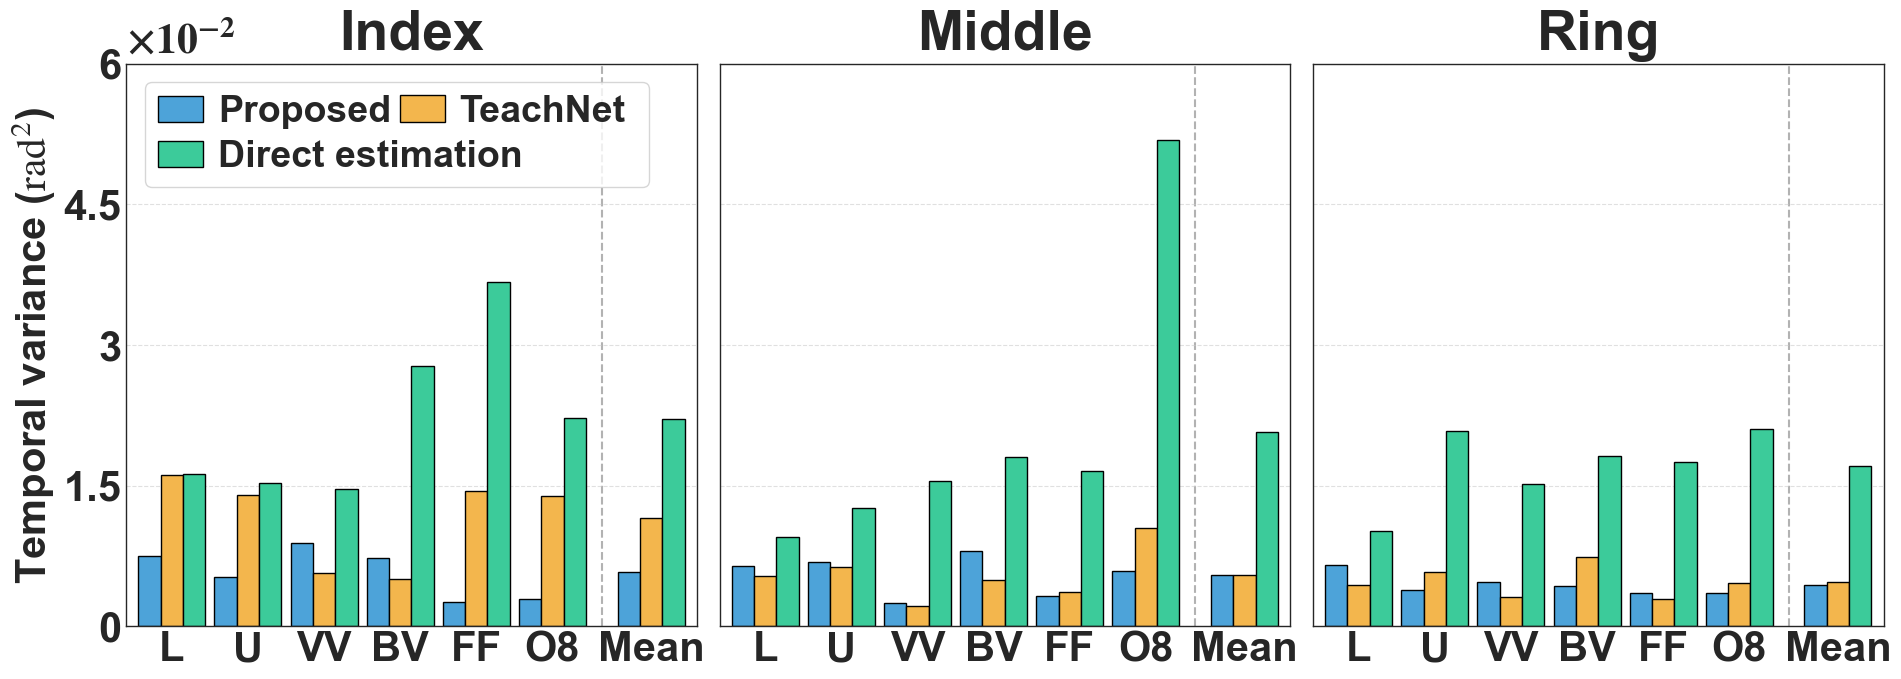

Final figure saved to: comparison_result.pdf

                             NUMERICAL RESULTS (Temporal Variance)                             

Finger: Index
-----------------------------------------------------------------------------------------------
Model        |          L |          U |         VV |         BV |         FF |         O8 |       Mean
-----------------------------------------------------------------------------------------------
Proposed     |   0.007476 |   0.005271 |   0.008908 |   0.007318 |   0.002590 |   0.002873 |   0.005739
TeachNet     |   0.016123 |   0.013955 |   0.005627 |   0.005025 |   0.014387 |   0.013875 |   0.011499
Direct estimation |   0.016219 |   0.015306 |   0.014659 |   0.027727 |   0.036751 |   0.022217 |   0.022147


Finger: Middle
-----------------------------------------------------------------------------------------------
Model        |          L |          U |         VV |         BV |         FF |         O8 |       Mean
-------------

In [34]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# =====================================================
# Font: Times New Roman (global)
# =====================================================
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams["axes.unicode_minus"] = False

# =====================================================
# Data preparation
# =====================================================

# (Assume mean_data is already defined)
euler_data    = np.transpose(mean_data[:, 0, :])
quat_data     = np.transpose(mean_data[:, 1, :])
no_euler_data = np.transpose(mean_data[:, 2, :])
rot6d_data    = np.transpose(mean_data[:, 3, :])
teach_data    = np.transpose(mean_data[:, 4, :])
GT_data       = np.transpose(mean_data[:, 5, :])

euler_mean    = euler_data.mean(axis=1, keepdims=True)
quat_mean     = quat_data.mean(axis=1, keepdims=True)
no_euler_mean = no_euler_data.mean(axis=1, keepdims=True)
rot6d_mean    = rot6d_data.mean(axis=1, keepdims=True)
teach_mean    = teach_data.mean(axis=1, keepdims=True)
GT_mean       = GT_data.mean(axis=1, keepdims=True)

all_data_full = [
    np.hstack((euler_data, euler_mean)),
    np.hstack((quat_data, quat_mean)),
    np.hstack((no_euler_data, no_euler_mean)),
    np.hstack((rot6d_data, rot6d_mean)),
    np.hstack((teach_data, teach_mean)),
    np.hstack((GT_data, GT_mean)),
]

colors_full = [
    "lightblue",
    "lightgreen",
    "lightcoral",
    "khaki",
    "plum",
    "mediumaquamarine",
]

names_full = ["Euler", "Quat", "No Rot", "Proposed", "TeachNet", "Direct estimation"]

# =====================================================
# >>> MODIFIED: keep only Rot 6D / TeachNet / Baseline
# =====================================================
keep_idx = [3, 4, 5]  # Rot 6D, TeachNet, Baseline
all_data = [all_data_full[k] for k in keep_idx]
# colors   = [colors_full[k]   for k in keep_idx]
colors = ["#4DA3D9", "#F3B64D", "#3CCB9A"]  # 더 선명한 색상으로 변경

names    = [names_full[k]    for k in keep_idx]
# =====================================================
# <<< END MODIFIED
# =====================================================

# =====================================================
# Plot configuration
# =====================================================

CAT_SPACING = 1.25
x = np.arange(7, dtype=float) * CAT_SPACING

BASE_SHIFT = 0.18
MEAN_GAP   = 0.55

x[:-1] += BASE_SHIFT
x[-1]  += MEAN_GAP

labels = pose_list + [r"$\mathbf{Mean}$"]
if len(labels) > 1:
    labels[1] = "U"
labels[-1] = "Mean"

titles = ["Index", "Middle", "Ring"]

# Font sizes
FS_TITLE  = 40
FS_LABEL  = 30
FS_TICK   = 30
FS_LEGEND = 27

# =====================================================
# Figure & layout
# =====================================================

fig, axes = plt.subplots(1, 3, figsize=(19, 7.5))

fig.subplots_adjust(
    left=0.06,
    right=0.985,
    bottom=0.15,
    top=0.9,
    wspace=0.04,
)

# =====================================================
# Formatter
# =====================================================

def specific_formatter(x, pos):
    val = x * 100
    if abs(val - round(val)) < 1e-9:
        return f"{int(val)}"
    else:
        return f"{val:.1f}"

# =====================================================
# Plot per finger
# =====================================================

Y_LIMIT = 0.06

n_models = len(all_data)
group_width = 1.1
width = group_width / n_models
offsets = (np.arange(n_models) - (n_models - 1) / 2.0) * width

RIGHT_PAD = 0.75
LEFT_PAD  = 0.75

for i, ax in enumerate(axes):
    for j, data in enumerate(all_data):
        bar_x = x + offsets[j]
        ax.bar(
            bar_x,
            data[i],
            width,
            label=names[j],
            color=colors[j],
            edgecolor="black",
            linewidth=1.0,
        )

    ax.axvline(
        x=(x[-2] + x[-1]) / 2.0,
        linestyle="--",
        linewidth=1.5,
        color="gray",
        alpha=0.6,
        zorder=0,
    )

    ax.set_title(titles[i], fontweight="bold", fontsize=FS_TITLE, pad=10)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=FS_LABEL, fontweight="bold")
    ax.set_xlim(x[0] - LEFT_PAD, x[-1] + RIGHT_PAD)

    if i == 0:
        ax.set_ylabel(
            r"Temporal variance ($\mathrm{rad}^2$)",
            fontsize=FS_LABEL,
            fontweight="bold",
        )
        ax.text(
            0.0,
            1.02,
            r"$\mathbf{\times 10^{-2}}$",
            transform=ax.transAxes,
            fontsize=FS_LABEL,
            fontweight="bold",
            ha="left",
        )
    else:
        ax.set_ylabel("")
        ax.tick_params(axis="y", labelleft=False)

    ax.tick_params(axis="x", labelsize=FS_TICK)
    ax.tick_params(axis="y", labelsize=FS_TICK)

    for label in ax.get_yticklabels():
        label.set_fontweight("bold")

    ax.grid(axis="y", linestyle="--", alpha=0.6)

    ax.set_ylim(0, Y_LIMIT)
    ax.set_yticks([0, 0.015, 0.03, 0.045, 0.06])
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(specific_formatter))

# =====================================================
# Legend
# =====================================================

# =====================================================
# Legend (swap TeachNet <-> Baseline order)
# =====================================================

# =====================================================
# Legend: two independent columns (tight TeachNet)
# =====================================================
handles, labels_leg = axes[0].get_legend_handles_labels()

# 현재 bar 추가 순서가 [Rot 6D, TeachNet, Model-free Baseline] 이라고 가정
# (labels_leg 값을 print로 확인해도 됩니다.)
idx_rot6d = labels_leg.index("Proposed")
idx_teach = labels_leg.index("TeachNet")
idx_base  = labels_leg.index("Direct estimation")

# Left legend (with frame)
# Left legend: force wider frame via bbox (axes coords)
leg_left = axes[0].legend(
    [handles[idx_rot6d], handles[idx_base]],
    [labels_leg[idx_rot6d], labels_leg[idx_base]],
    loc="upper left",
    bbox_to_anchor=(0.00, 1.00, 0.95, 0.001),  # (x0, y0, width, height) in axes fraction
    bbox_transform=axes[0].transAxes,
    mode="expand",  # expand legend box to fill bbox width
    frameon=True,
    prop={"size": FS_LEGEND, "weight": "bold"},
    borderpad=0.35,
    handlelength=1.2,
    handletextpad=0.4,
    labelspacing=0.3,
)

# Right legend: TeachNet (no frame, so it won't cover Baseline text)
leg_right = axes[0].legend(
    [handles[idx_teach]],
    [labels_leg[idx_teach]],
    loc="upper left",
    bbox_to_anchor=(0.42, 1.005),  # adjust x as needed
    bbox_transform=axes[0].transAxes,
    frameon=False,
    prop={"size": FS_LEGEND, "weight": "bold"},
    handlelength=1.2,
    handletextpad=0.4,
)

axes[0].add_artist(leg_left)

# =====================================================
# Save Figure
# =====================================================

save_filename = "comparison_result.pdf"

plt.savefig(
    save_filename,
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.25,
    bbox_extra_artists=(leg_left, leg_right),
    format="pdf",
)


plt.show()

print(f"Final figure saved to: {save_filename}")

# =====================================================
# Print Data Table
# =====================================================

print("\n" + "="*95)
print(f"{'NUMERICAL RESULTS (Temporal Variance)':^95}")
print("="*95 + "\n")

clean_labels = [l.replace(r"$\mathbf{Mean}$", "Mean") for l in labels]

for finger_idx, finger_name in enumerate(titles):
    print(f"Finger: {finger_name}")
    print("-" * 95)

    header_str = f"{'Model':<12} | " + " | ".join([f"{label:>10}" for label in clean_labels])
    print(header_str)
    print("-" * 95)

    for model_idx, model_name in enumerate(names):
        values = all_data[model_idx][finger_idx]
        val_str = " | ".join([f"{v:10.6f}" for v in values])
        print(f"{model_name:<12} | {val_str}")

    print("\n")


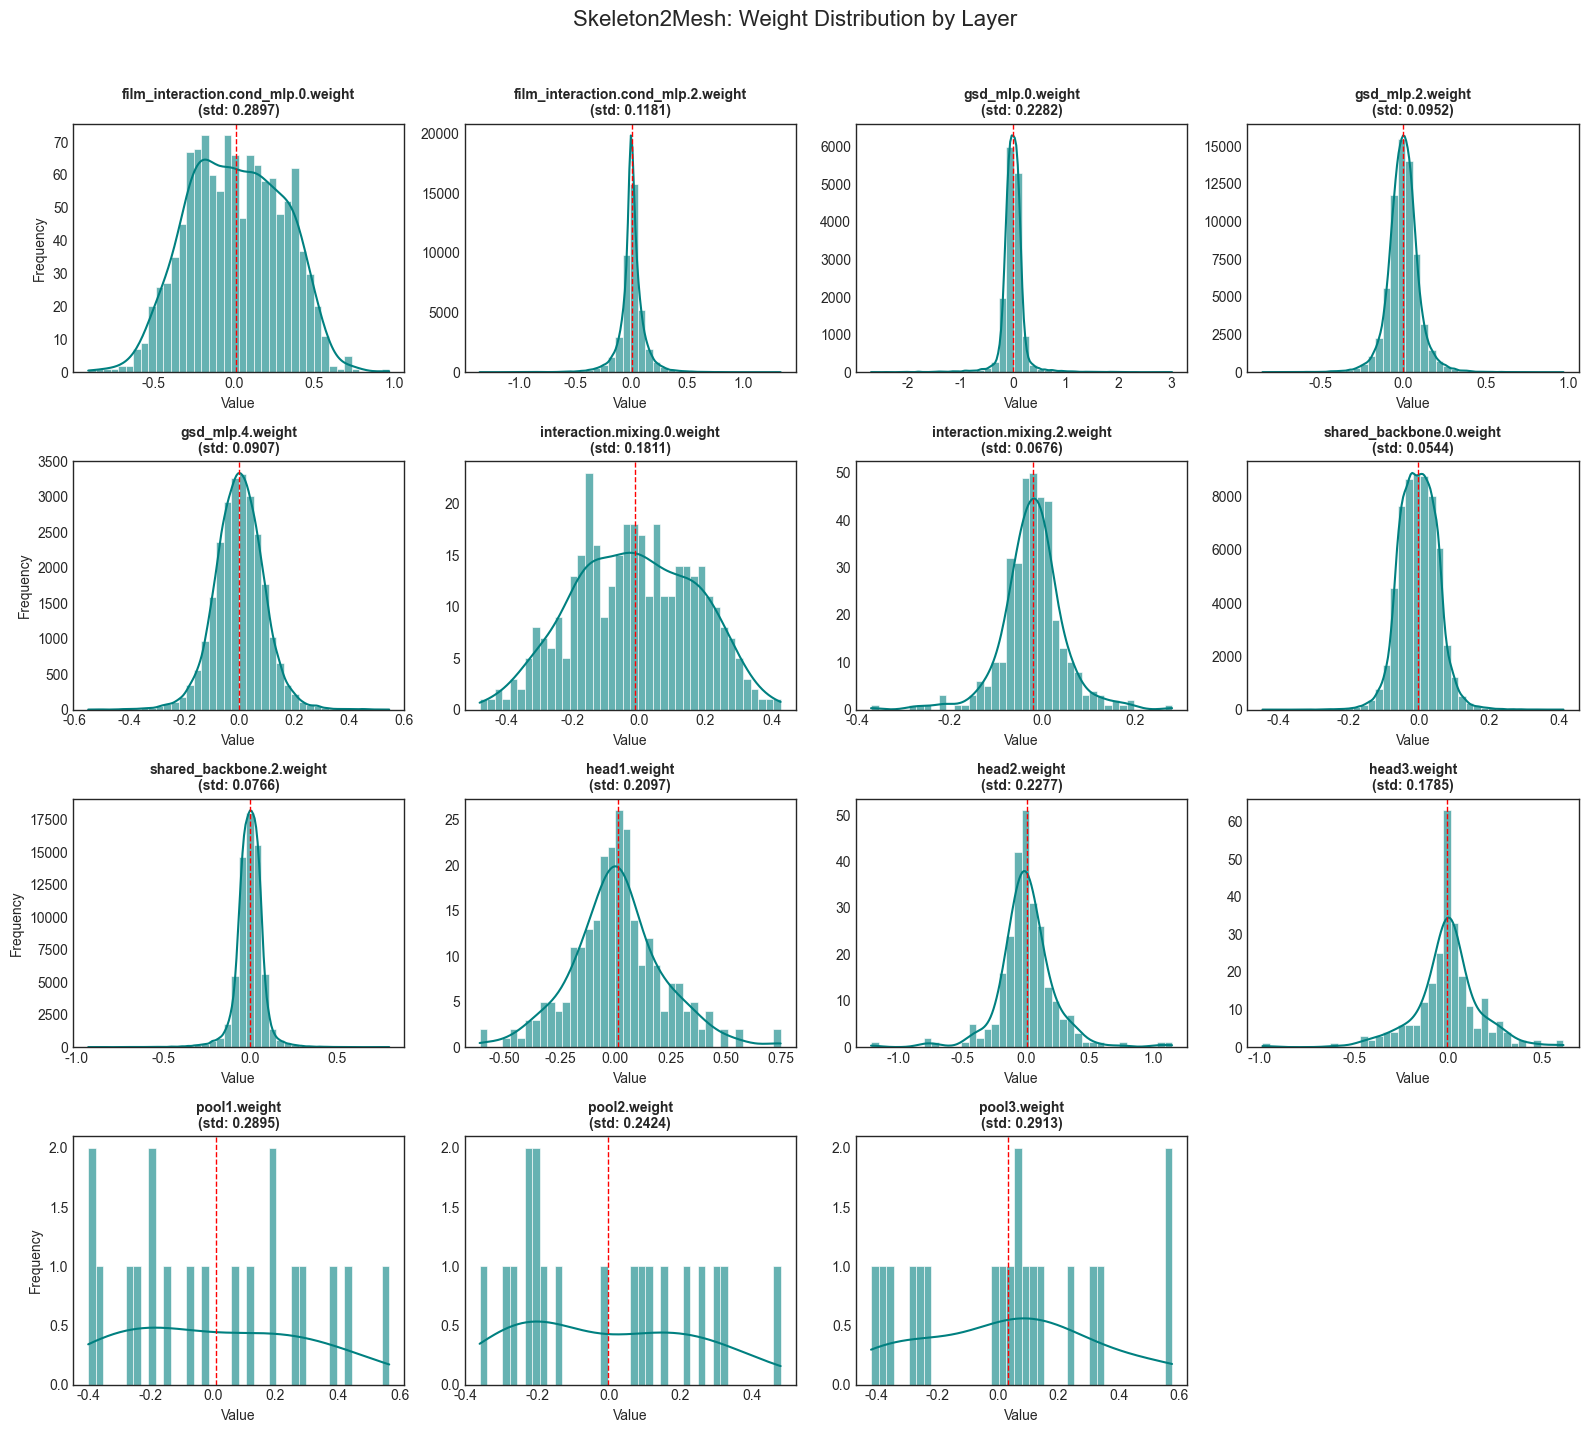

In [12]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_skeleton2mesh_weights(model):
    """
    Skeleton2Mesh 모델의 레이어별 가중치 분포를 시각화합니다.
    """
    # 1. 모델의 모든 파라미터 중 'weight'가 포함된 것만 추출
    # (Bias와 1차원 파라미터는 제외하고 행렬 형태의 가중치만 필터링)
    weights_to_plot = {}
    for name, param in model.named_parameters():
        if 'weight' in name and param.dim() > 1:
            weights_to_plot[name] = param.detach().cpu().numpy().flatten()

    if not weights_to_plot:
        print("시각화할 가중치 레이어를 찾지 못했습니다.")
        return

    # 2. 시각화 설정 (레이어 개수에 따라 유동적으로 그리드 생성)
    num_layers = len(weights_to_plot)
    cols = 4  # 한 줄에 보여줄 그래프 개수
    rows = (num_layers + cols - 1) // cols
    
    plt.figure(figsize=(cols * 4, rows * 3.5))
    sns.set_style("ticks")
    
    # 3. 레이어별 히스토그램 그리기
    for i, (name, w) in enumerate(weights_to_plot.items()):
        ax = plt.subplot(rows, cols, i + 1)
        
        # 히스토그램 + 밀도곡선(KDE)
        sns.histplot(w, kde=True, color='teal', bins=40, alpha=0.6)
        
        # 통계 정보 표시
        mean, std = np.mean(w), np.std(w)
        ax.set_title(f"{name}\n(std: {std:.4f})", fontsize=10, fontweight='bold')
        ax.axvline(mean, color='red', linestyle='--', linewidth=1, label=f'mean:{mean:.2f}')
        
        # 축 레이블 정리
        if i % cols == 0:
            ax.set_ylabel("Frequency")
        else:
            ax.set_ylabel("")
        ax.set_xlabel("Value")

    plt.suptitle("Skeleton2Mesh: Weight Distribution by Layer", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# --- 실행 방법 ---
# 1. 모델 인스턴스 생성 (설정값은 예시입니다)
# 3. 시각화 함수 실행
plot_skeleton2mesh_weights(rot6d_model)

===== GLOBAL STATISTICS (ALL CSVs) =====
total_samples : 66168
dt_mean [s]   : 0.016888
dt_std  [s]   : 0.003918
dt_min  [s]   : 0.001442
dt_max  [s]   : 0.057419
hz_mean [Hz]  : 62.588
hz_std  [Hz]  : 31.514
hz_min  [Hz]  : 17.416
hz_max  [Hz]  : 693.503

===== PERCENTILES (ALL CSVs) =====
p50 dt [ms] : 16.707 | p50 rate [Hz] (1/dt) : 59.86
p90 dt [ms] : 18.005 | p90 rate [Hz] (1/dt) : 55.54
p95 dt [ms] : 18.428 | p95 rate [Hz] (1/dt) : 54.26
p99 dt [ms] : 20.034 | p99 rate [Hz] (1/dt) : 49.92

===== PER-FILE DT SUMMARY =====
hz.csv
  count  : 14016
  mean   : 0.016929
  std    : 0.004261
  min    : 0.001589
  max    : 0.057025
hz_2.csv
  count  : 13415
  mean   : 0.016896
  std    : 0.004024
  min    : 0.001529
  max    : 0.056310
hz_3.csv
  count  : 11582
  mean   : 0.016805
  std    : 0.003164
  min    : 0.001632
  max    : 0.056959
hz_4.csv
  count  : 5203
  mean   : 0.016867
  std    : 0.003675
  min    : 0.001585
  max    : 0.055887
hz_5.csv
  count  : 21952
  mean   : 0.016905


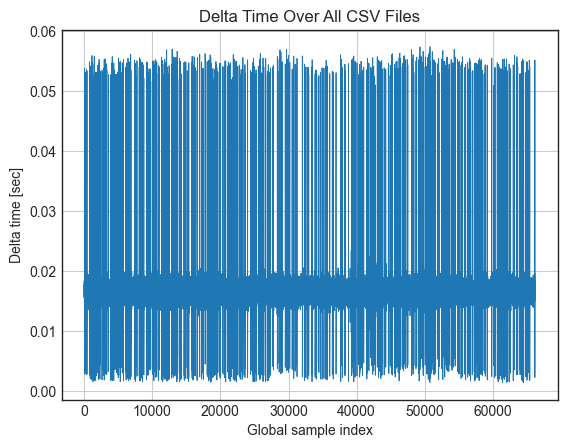

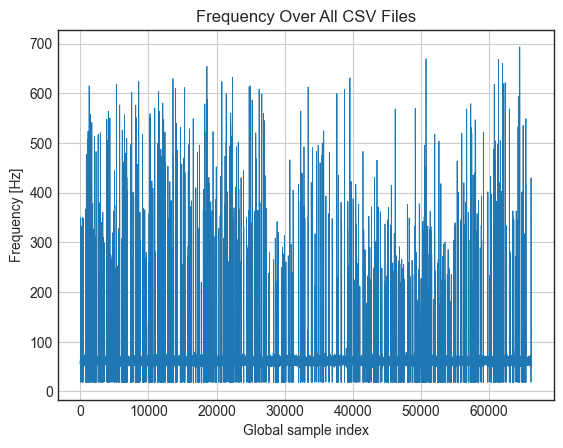

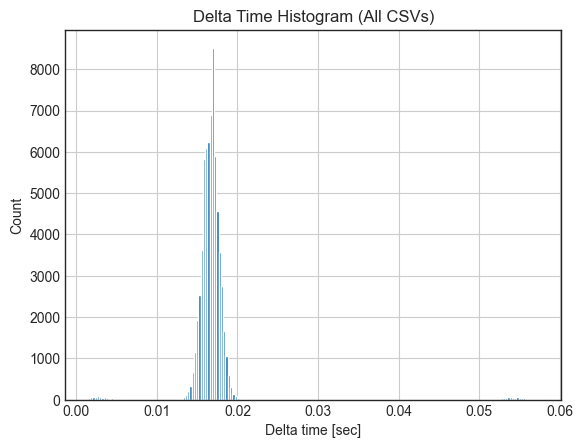

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

# ---- config ----
csv_dir = r"C:\Users\dyros\Desktop\dummy_ws\hz"   # directory containing csv files
csv_pattern = "*.csv"                             # pattern to match
timestamp_col = 0                                 # first column is timestamp
NS_TO_SEC = 1e-9
# ----------------

csv_files = glob.glob(os.path.join(csv_dir, csv_pattern))
assert len(csv_files) > 0, "No CSV files found"

all_dt = []
file_dt_stats = {}

for csv_path in csv_files:
    df = pd.read_csv(csv_path)

    # Extract timestamp (ns)
    t_ns = df.iloc[:, timestamp_col].astype(np.int64).values
    t = np.sort(t_ns * NS_TO_SEC)

    # Compute dt
    dt = np.diff(t)
    dt = dt[dt > 0]

    if len(dt) == 0:
        continue

    all_dt.append(dt)

    # Per-file stats (optional but useful)
    file_dt_stats[os.path.basename(csv_path)] = {
        "count": len(dt),
        "dt_mean": float(dt.mean()),
        "dt_std": float(dt.std()),
        "dt_min": float(dt.min()),
        "dt_max": float(dt.max()),
    }

# Concatenate all dt
all_dt = np.concatenate(all_dt)
all_hz = 1.0 / all_dt

# ---- percentile statistics (dt) ----
# Percentiles are more robust to jitter/outliers than mean/std.
p_list = [50, 90, 95, 99]
dt_p = np.percentile(all_dt, p_list)   # seconds
hz_p = 1.0 / dt_p                      # derived Hz from dt percentiles

# ---- global statistics ----
print("===== GLOBAL STATISTICS (ALL CSVs) =====")
print(f"total_samples : {len(all_dt)}")
print(f"dt_mean [s]   : {all_dt.mean():.6f}")
print(f"dt_std  [s]   : {all_dt.std():.6f}")
print(f"dt_min  [s]   : {all_dt.min():.6f}")
print(f"dt_max  [s]   : {all_dt.max():.6f}")
print(f"hz_mean [Hz]  : {all_hz.mean():.3f}")
print(f"hz_std  [Hz]  : {all_hz.std():.3f}")
print(f"hz_min  [Hz]  : {all_hz.min():.3f}")
print(f"hz_max  [Hz]  : {all_hz.max():.3f}")

# ---- percentile summary (recommended for paper) ----
print("\n===== PERCENTILES (ALL CSVs) =====")
for p, v_dt, v_hz in zip(p_list, dt_p, hz_p):
    print(f"p{p:02d} dt [ms] : {v_dt*1e3:.3f} | p{p:02d} rate [Hz] (1/dt) : {v_hz:.2f}")

# ---- per-file summary ----
print("\n===== PER-FILE DT SUMMARY =====")
for fname, s in file_dt_stats.items():
    print(f"{fname}")
    print(f"  count  : {s['count']}")
    print(f"  mean   : {s['dt_mean']:.6f}")
    print(f"  std    : {s['dt_std']:.6f}")
    print(f"  min    : {s['dt_min']:.6f}")
    print(f"  max    : {s['dt_max']:.6f}")

# ---- plotting ----

# 1. All dt over sample index
plt.figure()
plt.plot(all_dt, linewidth=0.6)
plt.xlabel("Global sample index")
plt.ylabel("Delta time [sec]")
plt.title("Delta Time Over All CSV Files")
plt.grid(True)
plt.show()

# 2. All Hz over sample index
plt.figure()
plt.plot(all_hz, linewidth=0.6)
plt.xlabel("Global sample index")
plt.ylabel("Frequency [Hz]")
plt.title("Frequency Over All CSV Files")
plt.grid(True)
plt.show()

# 3. Histogram of dt
plt.figure()
plt.hist(all_dt, bins=200)
plt.xlabel("Delta time [sec]")
plt.ylabel("Count")
plt.title("Delta Time Histogram (All CSVs)")
plt.grid(True)
plt.show()


In [14]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

total_params = count_parameters(rot6d_model)
trainable_params = count_trainable_parameters(rot6d_model)

print("===== ROT6D MODEL PARAMETERS =====")
print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")


===== ROT6D MODEL PARAMETERS =====
Total parameters     : 276,763
Trainable parameters : 276,763


In [15]:
# test = pd.read_csv('C:/Users/dyros/Desktop/dummy_ws/test_position.csv') # fix path


# position = test.iloc[:,10:-12]


# keywords = ['orientation', 'poses0', 'poses21', 'poses22', 'poses23', 'poses24', 'poses25']
# pattern = '|'.join(keywords)

# # 1) Find columns containing any of the keywords
# # mask_any_keyword = df_merged.columns.str.contains(pattern)
# mask_any_keyword = position.columns.str.contains(pattern)
# final_mask = ~mask_any_keyword 

# # 4) Apply mask to DataFrame
# # df_merged = df_merged.loc[:, final_mask]
# position_df = position.loc[:, final_mask]

# def visualize_hand_sequence(df, bone_parents, bone_children, skip_frames=1):
#     """
#     df: 입력 데이터프레임
#     bone_parents, bone_children: 뼈대 연결 정보
#     skip_frames: 데이터가 너무 많을 경우 몇 프레임마다 그릴지 설정 (기본 1: 모든 프레임)
#     """
    
#     # ---------------------------------------------------------
#     # 1. DataFrame에서 Landmark 좌표 추출 (Parsing)
#     # ---------------------------------------------------------
#     print("Extracting data from DataFrame...")
    
#     # 컬럼명에서 숫자(인덱스)와 축(x,y,z) 추출을 위한 정규식
#     # 예: field.pose_array.poses1.position.x -> index=1, axis='x'
#     pattern = re.compile(r'field\.pose_array\.poses(\d+)\.position\.([xyz])')
    
#     # 데이터프레임에 있는 모든 pose 인덱스 찾기
#     indices = set()
#     for col in df.columns:
#         match = pattern.search(col)
#         if match:
#             indices.add(int(match.group(1)))
    
#     sorted_indices = sorted(list(indices))
#     num_joints = len(sorted_indices)
    
#     if num_joints == 0:
#         raise ValueError("DataFrame에서 'field.pose_array.poses...' 형태의 컬럼을 찾을 수 없습니다.")
    
#     print(f"Detected {num_joints} joints. Indices: {sorted_indices[:5]} ... {sorted_indices[-5:]}")

#     # (Time, Joints, 3) 형태로 데이터 변환
#     num_frames = len(df)
#     data_3d = np.zeros((num_frames, num_joints, 3)) # (T, J, 3)
    
#     # DataFrame 컬럼 -> Numpy 배열 매핑
#     # sorted_indices의 순서대로 0번 조인트, 1번 조인트... 로 매핑합니다.
#     for i, original_idx in enumerate(sorted_indices):
#         for j, axis in enumerate(['x', 'y', 'z']):
#             col_name = f"field.pose_array.poses{original_idx}.position.{axis}"
#             if col_name in df.columns:
#                 data_3d[:, i, j] = df[col_name].values
#             else:
#                 print(f"Warning: Missing column {col_name}")

#     # 데이터 다운샘플링 (애니메이션 속도 및 렌더링 시간 최적화)
#     data_3d = data_3d[::skip_frames]
    
#     # ---------------------------------------------------------
#     # 2. 3D 애니메이션 설정
#     # ---------------------------------------------------------
#     print("Generating animation...")
    
#     fig = plt.figure(figsize=(8, 8))
#     ax = fig.add_subplot(111, projection='3d')
    
#     # 시각화 범위 고정 (데이터 전체의 min/max 기준)
#     # 이렇게 해야 손이 움직일 때 카메라가 흔들리지 않습니다.
#     all_x = data_3d[:, :, 0].flatten()
#     all_y = data_3d[:, :, 1].flatten()
#     all_z = data_3d[:, :, 2].flatten()
    
#     margin = 0.05
#     ax.set_xlim(all_x.min() - margin, all_x.max() + margin)
#     ax.set_ylim(all_y.min() - margin, all_y.max() + margin)
#     ax.set_zlim(all_z.min() - margin, all_z.max() + margin)
    
#     ax.set_xlabel('X')
#     ax.set_ylabel('Y')
#     ax.set_zlabel('Z')
#     ax.set_title("Hand Landmark Sequence")

#     # 초기화: 점(Scatter)과 선(Lines) 객체 생성
#     # joints: 각 랜드마크 점
#     scat = ax.scatter([], [], [], c='r', s=20, depthshade=True)
    
#     # bones: 뼈대 선분들
#     lines = []
#     # bone_parents와 bone_children을 묶어서 연결 정보 생성
#     connections = list(zip(bone_parents, bone_children))
    
#     for _ in connections:
#         line, = ax.plot([], [], [], 'b-', linewidth=1.5) # 파란색 실선
#         lines.append(line)

#     # ---------------------------------------------------------
#     # 3. 프레임 업데이트 함수
#     # ---------------------------------------------------------
#     def update(frame):
#         # 현재 프레임의 포즈 (Joints, 3)
#         current_pose = data_3d[frame] 
        
#         # 1. 점 업데이트
#         # scatter는 set_data(2D)와 set_3d_properties(Z)를 따로 해줘야 함 (Matplotlib 버전에 따라 다름)
#         # 가장 안전한 방법은 _offsets3d 프로퍼티를 직접 수정하는 것입니다.
#         scat._offsets3d = (current_pose[:, 0], current_pose[:, 1], current_pose[:, 2])
        
#         # 2. 선(Bone) 업데이트
#         for line, (parent, child) in zip(lines, connections):
#             # parent 인덱스와 child 인덱스가 데이터 범위 내에 있는지 확인
#             if parent < num_joints and child < num_joints:
#                 x_pts = [current_pose[parent, 0], current_pose[child, 0]]
#                 y_pts = [current_pose[parent, 1], current_pose[child, 1]]
#                 z_pts = [current_pose[parent, 2], current_pose[child, 2]]
                
#                 line.set_data(x_pts, y_pts)
#                 line.set_3d_properties(z_pts)
            
#         return [scat] + lines

#     # ---------------------------------------------------------
#     # 4. 애니메이션 생성 및 HTML 변환
#     # ---------------------------------------------------------
#     anim = animation.FuncAnimation(
#         fig, update, frames=len(data_3d), interval=50, blit=True
#     )
    
#     # Jupyter Notebook에 표시하기 위해 HTML로 변환
#     # to_jshtml()은 별도의 ffmpeg 설치 없이 브라우저 JS로 재생합니다.
#     return HTML(anim.to_jshtml())

# # =================================================================
# # 사용 예시 (User's Context)
# # =================================================================

# # 1. 토폴로지 정의 (주신 데이터)
# bone_parents = [0, 1, 2, 3,       # Thumb
#                 0, 5, 6, 7, 8,    # Index
#                 0, 10, 11, 12, 13, # Middle
#                 0, 15, 16, 17, 18  # Ring
#                ]

# bone_children = [1, 2, 3, 4,
#                  5, 6, 7, 8, 9,
#                  10,11,12,13,14,
#                  15,16,17,18,19]

# # 2. 실행 (df는 사용자의 DataFrame 변수라고 가정)
# # 만약 df가 이미 메모리에 있다면 아래 주석을 풀고 실행하세요.
# # 데이터가 너무 길면 skip_frames를 2, 5 등으로 늘리세요.

# visualize_hand_sequence(position_df, bone_parents, bone_children, skip_frames=1)

In [16]:
# import matplotlib.pyplot as plt
# import numpy as np

# plt.style.use('seaborn-v0_8-whitegrid')
# fig, ax = plt.subplots(figsize=(8, 6))

# mean_data = np.mean(data_array[:,:,:,:], axis=2)
# baseline_data = mean_data[:,0,:]
# teachnet_data = mean_data[:,1,:]
# nn_data = mean_data[:,2,:]

# # 파스텔톤 색상 (논문에서도 무난)
# colors = ['lightcoral', 'lightgreen', 'lightblue']

# # Boxplots (3 groups × 3 models)
# b1 = ax.boxplot(baseline_data, positions=[1, 5, 9], widths=0.6,
#                 patch_artist=True,
#                 boxprops=dict(facecolor=colors[0], alpha=0.8, edgecolor='black'),
#                 medianprops=dict(color='black', linewidth=1.2))
# b2 = ax.boxplot(teachnet_data, positions=[2, 6, 10], widths=0.6,
#                 patch_artist=True,
#                 boxprops=dict(facecolor=colors[1], alpha=0.8, edgecolor='black'),
#                 medianprops=dict(color='black', linewidth=1.2))
# b3 = ax.boxplot(nn_data, positions=[3, 7, 11], widths=0.6,
#                 patch_artist=True,
#                 boxprops=dict(facecolor=colors[2], alpha=0.8, edgecolor='black'),
#                 medianprops=dict(color='black', linewidth=1.2))

# # 축 설정
# ax.set_xticks([2, 6, 10])
# ax.set_xticklabels(['Index', 'Middle', 'Ring'], fontsize=12)
# ax.set_ylabel('Var', fontsize=13)
# ax.set_title('Variance Comparison per Finger', fontsize=14, fontweight='bold')

# # 범례
# ax.legend([b1["boxes"][0], b2["boxes"][0], b3["boxes"][0]],
#           ['Baseline', 'TeachNet', 'Ours'],
#           loc='upper right', fontsize=11, frameon=True, edgecolor='black')

# # 격자 및 외곽선 정리
# ax.grid(True, linestyle='--', alpha=0.5)
# for spine in ['top', 'right']:
#     ax.spines[spine].set_visible(False)

# plt.tight_layout()
# plt.show()


In [17]:
# baseline_data = mean_data[:,0,:]
# baseline_data.shape

In [18]:
# joint['%time'] = pd.to_numeric(joint['%time'])
# NN['%time'] = pd.to_numeric(NN['%time'])
# cols_to_add = ['field.data8', 'field.data9', 'field.data10']  
# merged = pd.merge_asof(
#     joint.sort_values('%time'), 
#     NN[['%time'] + cols_to_add].sort_values('%time'), 
#     on='%time',
#     direction='nearest'   
# )


In [19]:
# import pandas as pd
# import matplotlib.pyplot as plt

# # radTodeg = 180 / 3.14159265358979323846
# radTodeg = 1

# # Create subplots: 3 rows, 1 column
# fig, axes = plt.subplots(3, 1, figsize=(10, 12))
# name = ["index", "middle", "ring"]

# # Euler angle and finger columns for NN
# euler_angle_NN = merged.columns[0]
# finger_NN = merged.columns[5:8]

# # Euler angle and finger columns for baseline
# euler_angle_baseline = baseline.columns[0]
# finger_baseline = baseline.columns[3:6]

# # Plot loop
# for i, (row_NN, row_baseline) in enumerate(zip(finger_NN, finger_baseline)):
#     nn_norm =merged[row_NN] 
#     baseline_norm = baseline[row_baseline] * radTodeg

#     # variance 계산
#     var_nn = nn_norm.var()
#     var_baseline = baseline_norm.var()

#     axes[i].scatter(merged[euler_angle_NN], nn_norm,
#                     marker='o', linestyle='-', label="NN")
#     axes[i].scatter(baseline[euler_angle_baseline], baseline_norm,
#                     marker='s', linestyle='--', label="Baseline")

#     # variance annotation
#     axes[i].text(0.05, 0.95, 
#                  f"NN var={var_nn:.4e}\nBaseline var={var_baseline:.4e}", 
#                  transform=axes[i].transAxes,
#                  verticalalignment='top',
#                  fontsize=10,
#                  bbox=dict(facecolor='white', alpha=0.6))

#     axes[i].set_title(name[i])
#     axes[i].set_ylabel("Angle (deg)")
#     axes[i].grid(True)
#     axes[i].legend()


# # Add global title
# fig.suptitle("normalize plot", fontsize=16)

# plt.xlabel("Euler Angle")
# plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # leave space for suptitle
# plt.show()


In [20]:
# init=[-0.1278197169303894, 1.9431181728839875, 12.401289129257203]
# extend=[13.355320978164674, 10.181143426895142, -1.7475533306598663]

# init = np.array([-0.1278197169303894, 1.9431181728839875, 12.401289129257203])
# extend = np.array([13.355320978164674, 10.181143426895142, -1.7475533306598663])

# diff = extend - init  # shape (3,)
# diff = 15 * np.ones(3)

# # make sure NN[finger_NN] is numpy array with shape (N,3)
# modify = 0.35 * (NN[finger_NN] - init[None, :]) / diff[None, :]


In [21]:
# import pandas as pd
# import matplotlib.pyplot as plt

# # radTodeg = 180 / 3.14159265358979323846
# radTodeg = 1

# # Create subplots: 3 rows, 1 column
# fig, axes = plt.subplots(3, 1, figsize=(10, 12))
# name = ["index", "middle", "ring"]

# # Euler angle and finger columns for NN
# euler_angle_NN = NN.columns[0]
# finger_NN = NN.columns[3:6]

# # Euler angle and finger columns for baseline
# euler_angle_baseline = baseline.columns[0]
# finger_baseline = baseline.columns[3:6]

# # Plot loop
# for i, (row_NN, row_baseline) in enumerate(zip(finger_NN, finger_baseline)):
#     nn_norm = NN[row_NN] 
#     baseline_norm = baseline[row_baseline] * radTodeg

#     # variance 계산
#     var_nn = modify.iloc[:,i].var()
#     var_baseline = baseline_norm.var()

#     axes[i].scatter(NN[euler_angle_NN], modify.iloc[:,i],
#                     marker='o', linestyle='-', label="NN")
#     axes[i].scatter(baseline[euler_angle_baseline], baseline_norm,
#                     marker='s', linestyle='--', label="Baseline")

#     # variance annotation
#     axes[i].text(0.05, 0.95, 
#                  f"NN var={var_nn:.4e}\nBaseline var={var_baseline:.4e}", 
#                  transform=axes[i].transAxes,
#                  verticalalignment='top',
#                  fontsize=10,
#                  bbox=dict(facecolor='white', alpha=0.6))

#     axes[i].set_title(name[i])
#     axes[i].set_ylabel("Angle (deg)")
#     axes[i].grid(True)
#     axes[i].legend()


# # Add global title
# fig.suptitle("normalize plot", fontsize=16)

# plt.xlabel("Euler Angle")
# plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # leave space for suptitle
# plt.show()


In [22]:
# import numpy as np
# import matplotlib.pyplot as plt

# # Extract data
# vec1 = modify.iloc[:, 0].values          # shape (N,)
# vec2 = NN[finger_NN[0]]                 # shape (3,)

# # Normalize function (min-max normalization)
# def normalize(x):
#     return (x - np.min(x)) / (np.max(x) - np.min(x))

# # Normalize both vectors
# vec1_norm = normalize(vec1)
# vec2_norm = normalize(vec2)

# # Plot
# plt.figure(figsize=(8, 5))

# # vec1 is 1D with length N, plot against its index
# plt.plot(vec1_norm, label="modify.iloc[:,0] (normalized)", marker='o')

# # vec2 is length 3, plot against index 0,1,2
# plt.plot(range(len(vec2_norm)), vec2_norm, label="NN[finger_NN[0]] (normalized)", marker='x')

# plt.xlabel("Index")
# plt.ylabel("Normalized value")
# plt.title("Normalized Comparison")
# plt.legend()
# plt.grid(True)
# plt.show()
